<a href="https://colab.research.google.com/github/hafsaaslam1212-star/UrbanMobility-DataAnalytics/blob/main/Big_Data_Analytics_using_Apache_Spark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
BASE = "/content/drive/MyDrive/northstar_data/northstar_dataset/"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

BASE = "/content/drive/MyDrive/northstar_data/northstar_dataset/"
print(os.listdir(BASE))

['complaints.csv', 'deliveries.csv', 'orders.csv', 'data_dictionary.csv', 'app_events.csv', 'drivers.csv', 'hubs.csv', 'README.txt', 'vehicles.csv', 'customers.csv', 'incidents.csv']


In [ ]:
BASE = "/content/drive/MyDrive/northstar_data/northstar_dataset/"

df = spark.read.csv(
    BASE + "deliveries.csv",
    header=True,
    inferSchema=True
)

In [ ]:
df = spark.read.csv(
    "/content/drive/MyDrive/northstar_data/northstar_dataset/deliveries.csv",
    header=True,
    inferSchema=True
)

In [ ]:
import os

BASE = "/content/drive/MyDrive/northstar_data/northstar_dataset/"
print(os.listdir(BASE))

['complaints.csv', 'deliveries.csv', 'orders.csv', 'data_dictionary.csv', 'app_events.csv', 'drivers.csv', 'hubs.csv', 'README.txt', 'vehicles.csv', 'customers.csv', 'incidents.csv']


In [ ]:
df = spark.read.csv(
    "/content/drive/MyDrive/northstar_data/northstar_dataset/deliveries.csv",
    header=True,
    inferSchema=True
)

In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "deliveries.csv" in files:
        print("FOUND AT:", root)

FOUND AT: /content/drive/MyDrive/northstar_data/northstar_dataset


In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("NorthStar Analytics") \
    .getOrCreate()

df = spark.read.csv(
    "/content/drive/MyDrive/northstar_data/northstar_dataset/deliveries.csv",
    header=True,
    inferSchema=True
)

df.show(5)

+-----------+--------+---------+----------+------+-------------------+---------------------+---------------+-----------------+---------------------------+---------------------------+-----------------------------+-------------------+
|delivery_id|order_id|driver_id|vehicle_id|hub_id|      dispatch_time|delivery_completed_at|delivery_status|route_distance_km|manual_route_override_count|proof_of_completion_missing|customer_rating_post_delivery|fuel_or_charge_cost|
+-----------+--------+---------+----------+------+-------------------+---------------------+---------------+-----------------+---------------------------+---------------------------+-----------------------------+-------------------+
|    DL00001|  O00938|     D004|      V056|   H05|2024-06-18 10:57:00| 2024-06-19 09:05:...|         Failed|            17.26|                          1|                          0|                         3.07|              12.05|
|    DL00002|  O00004|     D138|      V007|   H02|2025-01-11 18:45:0

In [3]:
pandas_df = df.limit(5).toPandas()

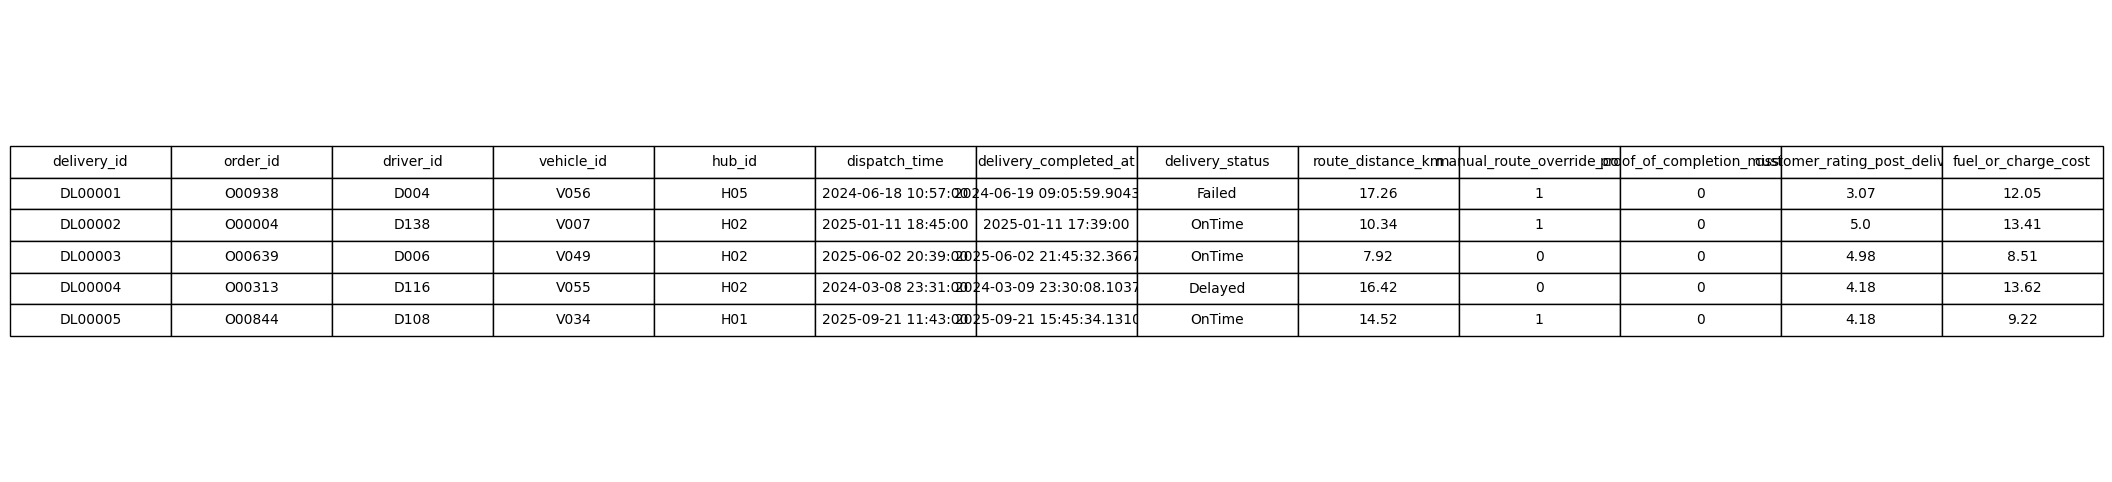

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(18, 6))
ax.axis('off')

table = ax.table(
    cellText=pandas_df.values,
    colLabels=pandas_df.columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.5, 1.9)

plt.savefig("delivery_table.png", dpi=300, bbox_inches='tight')
plt.show()


In [5]:
df.groupBy("delivery_status").count().show()

+---------------+-----+
|delivery_status|count|
+---------------+-----+
|         OnTime|  616|
|         Failed|  132|
|        Delayed|  202|
+---------------+-----+



In [6]:
df.groupBy("hub_id").avg("customer_rating_post_delivery").show()

+------+----------------------------------+
|hub_id|avg(customer_rating_post_delivery)|
+------+----------------------------------+
|   H07|                3.8818584070796485|
|   H08|                           3.88456|
|   H03|                 3.895862068965517|
|   H04|                3.9154761904761903|
|   H05|                 3.669557522123895|
|   H01|                3.8405925925925937|
|   H02|                  3.95095238095238|
|   H06|                3.8821359223300966|
+------+----------------------------------+



In [7]:
df.groupBy("delivery_status").avg("route_distance_km").show()

+---------------+----------------------+
|delivery_status|avg(route_distance_km)|
+---------------+----------------------+
|         OnTime|    13.776363636363648|
|         Failed|    13.365303030303034|
|        Delayed|     14.67024752475248|
+---------------+----------------------+



In [8]:
df.groupBy("driver_id") \
  .avg("customer_rating_post_delivery") \
  .orderBy("avg(customer_rating_post_delivery)", ascending=False) \
  .show()

+---------+----------------------------------+
|driver_id|avg(customer_rating_post_delivery)|
+---------+----------------------------------+
|     D035|                               5.0|
|     D059|                               5.0|
|     D065|                4.9350000000000005|
|     D122|                 4.716666666666666|
|     D118|                4.6625000000000005|
|     D025|                 4.653333333333333|
|     D061|                 4.609999999999999|
|     D081|                               4.6|
|     D066|                              4.56|
|     D015|                 4.521666666666667|
|     D013|                            4.5175|
|     D003|                             4.445|
|     D138|                            4.4375|
|     D126|                             4.428|
|     D014|                            4.4275|
|     D108|                 4.411818181818181|
|     D044|                              4.38|
|     D012|                              4.38|
|     D163|  

In [9]:
from pyspark.sql.functions import when, avg

df = df.withColumn(
    "is_delayed",
    when(df.delivery_status == "Delayed", 1).otherwise(0)
)

df.groupBy("hub_id").avg("is_delayed").show()

+------+-------------------+
|hub_id|    avg(is_delayed)|
+------+-------------------+
|   H07|0.21739130434782608|
|   H08|           0.171875|
|   H03|0.19327731092436976|
|   H04| 0.2204724409448819|
|   H05|0.21739130434782608|
|   H01|0.19117647058823528|
|   H02|0.24528301886792453|
|   H06|0.25961538461538464|
+------+-------------------+

